# BioSED: Notebook 3 - Entrenamiento de la Red Neuronal Convolucional Recurrente (CRNN)

## 1. Introducción y Objetivos de la Fase de Modelado

En esta etapa del proyecto abordamos el núcleo del modelado predictivo: el **Entrenamiento de la Red Convolucional Recurrente (CRNN)** para la Detección de Eventos Sonoros Bioacústicos (BioSED) [5]. Utilizaremos los datos de audio digitalizados y las pseudo-etiquetas de tiempo unificadas y validadas en la Fase 1, fundamentados en las relaciones físicas y las representaciones perceptotemporales (Log-Mel) que analizamos en la Fase 2 [5].

El objetivo primordial de este notebook es diseñar, optimizar y persistir una arquitectura supervisada profunda capaz de inferir de forma independiente y temporal múltiples especies de aves silvestres de Medellín frame-a-frame [5].

Los objetivos específicos de esta fase de modelado son:
1.  **Verificación de Entradas**: Implementar un control de calidad automatizado para garantizar que el entrenamiento se ejecute sobre datos consistentes y localizados físicamente [5].
2.  **Mitigación de Fuga de Información (*Data Leakage*)**: Diseñar una división estricta de conjuntos de entrenamiento, validación y prueba a nivel de clip (archivo de audio), asegurando que los segmentos de un mismo archivo nunca se compartan entre splits [5].
3.  **Alineación Temporal Correcta (Resolución de Bug)**: Implementar una clase `Dataset` que extraiga ventanas de 10 segundos centradas de forma dinámica en las detecciones, garantizando que el modelo entrene asociando espectrogramas válidos con sus respectivas marcas temporales de canto [5].
4.  **Implementación de la Arquitectura CRNN**: Estructurar una red que combine capas de convolución 2D (CNN para extraer la firma visual geométrica de los armónicos) con capas recurrentes bidireccionales de compuerta (BiGRU para capturar el contexto dinámico de inicio y fin de la vocalización).
5.  **Entrenamiento y Persistencia**: Optimizar el modelo mediante la pérdida de Entropía Cruzada Binaria (BCE) por frame, graficar su evolución numérica de convergencia y guardar el checkpoint oficial consolidado con todos los metadatos de audio necesarios para su despliegue [5].

## 2. Configuración General del Entorno y Reproducibilidad

Para garantizar que la fase de modelado sea completamente reproducible y autocontenida, importaremos las dependencias necesarias de PyTorch para el diseño de arquitecturas neuronales profundas (`torch`, `nn`, `optim`, `DataLoader`), utilidades de análisis de señales acústicas (`librosa`, `torchaudio`), manipulación de datos tabulares (`pandas`, `numpy`) y visualización de entrenamiento (`matplotlib`, `seaborn`).

Estableceremos de forma estricta las rutas relativas subiendo un nivel hacia el directorio raíz (`../dataset_aves` y `../artifacts`) y forzaremos el determinismo en todas las librerías configurando una semilla global fija (`SEED = 42`) [5]. Esto es una práctica metodológica indispensable en aprendizaje estadístico para garantizar que cualquier inicialización de pesos, partición de datos o gradiente calculado sea idéntico en ejecuciones sucesivas, permitiendo auditorías reales del modelo.

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import torchaudio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Desactivar advertencias de deprecación estéticas de las librerías de audio y visualización
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Configuración estética global para visualizaciones de curvas de pérdida
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (8, 4)

# 1. Configurar determinismo estricto para reproducibilidad de gradientes, pesos y splits
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Forzar comportamiento determinista en algoritmos de convolución de CUDA (cuDNN)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 2. Definición de rutas relativas (subiendo un nivel desde la carpeta notebooks/)
BASE_DIR = "../dataset_aves"
METADATA_PATH = os.path.join(BASE_DIR, "df_metadata_audios.csv")
LABELS_PATH = os.path.join(BASE_DIR, "df_etiquetas_fuertes.csv")
ARTIFACTS_DIR = "../artifacts"

# Detectar el hardware de cómputo disponible en la máquina (GPU/CUDA o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Entorno de modelado inicializado con éxito:")
print(f"  - Semilla global de reproducibilidad establecida: {SEED}")
print(f"  - Dispositivo de cómputo activo para entrenamiento: {device}")

Entorno de modelado inicializado con éxito:
  - Semilla global de reproducibilidad establecida: 42
  - Dispositivo de cómputo activo para entrenamiento: cuda


## 3. Control de Calidad y Verificación de Consistencia del Dataset

### 3.1. Auditoría Programática de Entradas
Antes de estructurar el modelo, instanciar las capas de convolución o configurar los optimizadores de PyTorch, realizaremos un control de calidad automatizado y estricto sobre el sistema de archivos local [5]. Esto garantiza la estabilidad del entrenamiento, previniendo excepciones silenciosas de desajuste de dimensiones o rutas inexistentes durante las futuras iteraciones del bucle de gradiente [5].

Si la auditoría detecta algún error en tu máquina local, el script detendrá de forma controlada la ejecución (`AssertionError`) e imprimirá una caja con instrucciones claras para recuperar el dataset ejecutando el **Notebook 01 (Adquisición de Datos y Pseudo-Etiquetado)** [5].

In [2]:
# Lista para registrar las inconsistencias detectadas
inconsistencias = []

print("=== INICIANDO CONTROL DE CALIDAD DEL CORPUS ACÚSTICO ===")

# 1. Verificar existencia física e integridad del archivo de metadatos de audios
if os.path.exists(METADATA_PATH):
    df_check_meta = pd.read_csv(METADATA_PATH)
    if len(df_check_meta) > 0:
        print(f"  [OK] df_metadata_audios.csv presente. Registros indexados: {len(df_check_meta)}")
    else:
        inconsistencias.append("El archivo df_metadata_audios.csv está vacío en disco.")
else:
    inconsistencias.append(f"No se encuentra df_metadata_audios.csv en la ruta: {METADATA_PATH}")

# 2. Verificar existencia física e integridad del archivo de etiquetas fuertes
if os.path.exists(LABELS_PATH):
    df_check_labels = pd.read_csv(LABELS_PATH)
    if len(df_check_labels) > 0:
        print(f"  [OK] df_etiquetas_fuertes.csv presente. Segmentos de canto: {len(df_check_labels)}")
    else:
        inconsistencias.append("El archivo df_etiquetas_fuertes.csv está vacío en disco.")
else:
    inconsistencias.append(f"No se encuentra df_etiquetas_fuertes.csv en la ruta: {LABELS_PATH}")

# 3. Verificar directorios físicos de audio por especie y su conteo de archivos MP3
especies_lista_test = [
    "Turdus ignobilis", "Pitangus sulphuratus", "Thraupis episcopus", 
    "Zonotrichia capensis", "Tyrannus melancholicus", "Pygochelidon cyanoleuca", 
    "Troglodytes aedon", "Crotophaga ani", "Thraupis palmarum", "Campylorhynchus griseus"
]

carpetas_encontradas = 0
total_mp3_contados = 0

for esp in especies_lista_test:
    carpeta_esp = os.path.join(BASE_DIR, esp.replace(" ", "_"))
    if os.path.isdir(carpeta_esp):
        carpetas_encontradas += 1
        archivos_mp3 = [f for f in os.listdir(carpeta_esp) if f.endswith(".mp3")]
        total_mp3_contados += len(archivos_mp3)
    else:
        inconsistencias.append(f"Falta la carpeta física de la especie: '{esp}' en la ruta: {BASE_DIR}")

print(f"  [OK] Carpetas físicas de especies validadas: {carpetas_encontradas}/10")
print(f"  [OK] Archivos de audio .mp3 detectados en disco: {total_mp3_contados}")

# 4. Verificar existencia de la carpeta de artefactos de salida del entrenamiento
if os.path.exists(ARTIFACTS_DIR):
    print(f"  [OK] Directorio de artefactos presente: '{ARTIFACTS_DIR}'")
else:
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)
    print(f"  [Advertencia] Directorio de artefactos creado en la ruta: '{ARTIFACTS_DIR}'")

# 5. Evaluar veredicto de la auditoría y emitir instrucciones claras de recuperación si falla
print("\n=== VEREDICTO DE LA AUDITORÍA ===")
if len(inconsistencias) == 0:
    print("ESTADO: CORPUS CONSISTENTE. Puedes proceder de forma segura con la etapa de modelado.")
else:
    print("ESTADO: CORPUS INCONSISTENTE. No se puede iniciar el entrenamiento.")
    print("\n--------------------------------------------------------------------------------")
    print("                       INSTRUCCIONES DE RECUPERACIÓN                            ")
    print("--------------------------------------------------------------------------------")
    print("Se detectaron los siguientes errores en tu entorno:")
    for err in inconsistencias:
        print(f"  * [FALTA] {err}")
    print("\nACCIÓN REQUERIDA:")
    print("  1. Abre y ejecuta completamente el Notebook '01_dataset_y_etiquetado.ipynb'.")
    print("  2. Configura la variable 'MAX_ARCHIVOS_POR_ESPECIE = 120' para descargar el dataset completo.")
    print("  3. Una vez finalizada la ejecución de la Fase 1, regresa aquí y vuelve a correr esta celda.")
    print("--------------------------------------------------------------------------------\n")
    raise AssertionError("El corpus acústico local no se encuentra completo o consistente.")

=== INICIANDO CONTROL DE CALIDAD DEL CORPUS ACÚSTICO ===
  [OK] df_metadata_audios.csv presente. Registros indexados: 751
  [OK] df_etiquetas_fuertes.csv presente. Segmentos de canto: 5641
  [OK] Carpetas físicas de especies validadas: 10/10
  [OK] Archivos de audio .mp3 detectados en disco: 751
  [OK] Directorio de artefactos presente: '../artifacts'

=== VEREDICTO DE LA AUDITORÍA ===
ESTADO: CORPUS CONSISTENTE. Puedes proceder de forma segura con la etapa de modelado.


### 3.2. Protocolo de Mitigación y Recuperación de Datos

Para asegurar que el flujo de trabajo sea robusto frente a fallos y transportable a cualquier entorno de cómputo limpio (por ejemplo, si tu compañero de equipo ejecuta este notebook en su máquina local sin haber copiado previamente las señales de audio), la celda de validación anterior implementa un control de excepciones asertivo (`AssertionError`) [5].

En caso de que el sistema detecte la ausencia de cualquiera de las bases de datos de control unificadas o la falta de archivos físicos de audio en las carpetas taxonómicas, la ejecución se interrumpirá de inmediato para evitar que el bucle de entrenamiento falle a mitad de proceso, desplegando un protocolo interactivo detallado con tres pasos de recuperación prioritarios [5]:
1.  **Ejecutar el Notebook 01** para reconstruir de forma automatizada las descargas y el pseudo-etiquetado temporal [5].
2.  **Configurar el volumen masivo de datos** asegurando que la variable `MAX_ARCHIVOS_POR_ESPECIE` esté fijada en `120` [5].
3.  **Re-ejecutar la auditoría** para habilitar la luz verde de consistencia del dataset [5].

## 4. Formulación del Problema desde el Aprendizaje Estadístico

### 4.1. Formalización Matemática del Sistema BioSED

Desde la perspectiva del Aprendizaje Estadístico (*Statistical Machine Learning*), modelamos la tarea de Detección de Eventos Sonoros Bioacústicos como un problema supervisado de mapeo secuencial y asignación de etiquetas múltiples estructurado en el tiempo.

Para cada grabación de audio indexada por el entero $i$ en nuestro conjunto de datos, definimos formalmente los siguientes espacios:

#### 4.1.1. El Espacio de Entrada (Features)
La entrada física del clasificador es la representación espectral Log-Mel bidimensional $X_i$ que resume la energía de la señal acústica:
$$X_i \in \mathbb{R}^{T \times F}$$

Donde:
*   $T$: Número total de frames temporales que conforman la secuencia (eje del tiempo). Para nuestro recorte fijo de 10 segundos con una frecuencia de muestreo $f_s = 32\text{ kHz}$ y un desplazamiento de ventana $H = 512$ muestras, la secuencia consta de una longitud temporal de $T = 626$ frames [5].
*   $F$: Número de bines o canales de frecuencia psicoacústica de Mel. En nuestro diseño, $F = 64$ filtros Mel [5].

#### 4.1.2. El Espacio de Salida Objetivo (Targets)
La salida esperada de supervisión es una matriz binaria bidimensional $Y_i$ que codifica la presencia o ausencia de cantos activos a lo largo del tiempo:
$$Y_i \in \{0, 1\}^{T \times C}$$

Donde:
*   $C$: Número total de clases independientes (especies de aves). En nuestro sistema, $C = 10$ especies seleccionadas de Medellín [5].
*   $y_{i, t, c} = 1$ indica que la especie de ave $c$ está emitiendo una vocalización activa durante el frame temporal $t$ en el archivo de audio $i$ [5].
*   $y_{i, t, c} = 0$ denota silencio o ausencia de canto de la especie $c$ en ese instante específico de tiempo [5].

#### 4.1.3. El Modelo Paramétrico de Inferencia
Diseñaremos y optimizaremos un modelo continuo parametrizado por un vector de pesos $\theta$ (los pesos sinápticos de la red convolucional recurrente):
$$f_\theta(X_i) \in [0, 1]^{T \times C}$$

Este estimador calcula y aproxima de forma numérica la probabilidad condicional de que la especie $c$ esté cantando en el instante $t$, dado el contexto de la señal Log-Mel $X_i$:
$$p_{i, t, c} = f_\theta(X_i)_{t, c} \approx P(Y_{i, t, c} = 1 \mid X_i)$$

Dado que las aves se comunican en un paisaje sonoro donde la polifonía es común, el modelo no asume exclusión mutua [5]. De este modo, la red estima de forma independiente $C$ probabilidades continuas entre $0.0$ y $1.0$ por cada frame temporal individual $t$ [5].

### 4.2. El Paradigma Multi-Etiqueta a Nivel de Cuadro de Tiempo (Multi-Label Frame-Level)

En la clasificación convencional de audio, el modelo estima un único vector de probabilidad a nivel de clip completo. Dicho esquema asume de forma implícita la hipótesis de exclusión mutua: si la señal contiene la especie $A$, se reduce probabilísticamente la presencia de la especie $B$. 

Este paradigma clásico colapsa ante el problema de **Detección de Eventos Sonoros (SED)** debido a dos particularidades físicas y matemáticas de la señal bioacústica:

#### 4.2.1. Resolución Temporal Densa (Frame-Level)
El modelo no emite un único veredicto global para el audio de 10 segundos, sino que realiza una serie ordenada de $T$ predicciones cronológicas consecutivas [5]. Esto convierte el problema en un sistema de segmentación temporal densa, estimando el estado de activación del paisaje sonoro en intervalos de $\approx 16 \text{ ms}$ (resolución dada por nuestro salto $H = 512$ a $32 \text{ kHz}$):
$$\mathbf{p}_t = [p_{t,1}, p_{t,2}, \dots, p_{t,C}] \in [0, 1]^C, \quad \forall t \in [0, T-1]$$

#### 4.2.2. Superposición de Fuentes (Polifonía) y el Fallo de Softmax
Como determinamos en el análisis de polifonía del EDA, es común que múltiples especies vocalicen simultáneamente en el mismo instante [5]. Obligar al modelo a utilizar una función de activación *Softmax* en la capa de predicción final forzaría una normalización estricta donde la suma de las probabilidades de todas las clases sea $1.0$:
$$\sum_{c=1}^{C} p_{t,c} = 1.0$$

Bajo la restricción de *Softmax*, si el canto potente y cercano de un *Pitangus sulphuratus* (Bichofué) eleva su probabilidad a $p_{t,\text{Bichofue}} = 0.90$, la probabilidad de una *Turdus ignobilis* (Mirla) cantando suavemente en segundo plano se vería matemáticamente acotada a un valor estrictamente inferior a $0.10$, induciendo falsos negativos artificiales debido a un acoplamiento matemático erróneo.

#### 4.2.3. Activación por Sigmoide Independiente
Para solucionar esto, modelamos la capa de salida final aplicando la función de activación **Sigmoide ($\sigma$)** de forma paralela e independiente sobre cada una de las $C$ neuronas de salida para cada frame temporal $t$ [5]:
$$p_{t,c} = \sigma(z_{t,c}) = \frac{1}{1 + e^{-z_{t,c}}} \in [0, 1]$$

Donde $z_{t,c}$ representa el valor lineal de salida (*logit*) calculado por la red neuronal para el frame de tiempo $t$ y la clase $c$.

Esta formulación matemática confiere tres propiedades analíticas indispensables al sistema:
1.  **Polifonía nativa**: Permite a la red predecir que múltiples especies cantan de forma simultánea si sus respectivas salidas superan el umbral (por ejemplo, estimar de forma concurrente $p_{t,\text{Bichofue}} = 0.85$ y $p_{t,\text{Mirla}} = 0.91$) [5].
2.  **Soporte de silencios**: Si en un tramo de tiempo no hay cantos activos de las especies estudiadas (los audios "mudos" identificados en el EDA), todas las neuronas de salida pueden converger libremente a valores cercanos a $0.0$ de manera simultánea [5].
3.  **Desacoplamiento de gradientes**: El ajuste de pesos para aprender a identificar una especie se realiza sin competir ni restarle probabilidad matemática a las especies restantes [5].

### 4.3. Alineación Temporal de la Matriz de Objetivos (target_matrix)

La construcción de la matriz de objetivos de supervisión $Y_i \in \{0, 1\}^{T \times C}$ exige transformar las coordenadas temporales continuas en segundos (marcas de inicio $t_{\text{inicio}}$ y fin $t_{\text{fin}}$ de las vocalizaciones) a índices discretos de frames temporales $f \in [0, T-1]$ [5].

#### 4.3.1. Mapeo de Tiempo a Índices de Frames
Físicamente, la relación de conversión está regida por la tasa de muestreo del audio digitalizado $f_s$ y el factor de desplazamiento del ventanamiento (*Hop Length* $H$ muestras):
$$\text{frame}(t) = \text{round}\left( \frac{t \cdot f_s}{H} \right)$$

Para un evento acústico indexado por $k$ que ocurre en el intervalo continuo $[t_{\text{inicio}}, t_{\text{fin}}]$, activamos la máscara de supervisión con un valor de $1.0$ en el rango discreto de filas de la matriz:
$$\text{start\_frame} = \text{round}\left( \frac{t_{\text{inicio}, k} \cdot f_s}{H} \right), \quad \text{end\_frame} = \text{round}\left( \frac{t_{\text{fin}, k} \cdot f_s}{H} \right)$$

#### 4.3.2. El Bug de Desalineación Temporal de 10 Segundos Revelado por el EDA
El Análisis Exploratorio de Datos (EDA) reveló que la mediana del inicio de los cantos de aves se localiza en $24.0$ segundos, extendiéndose en audios largos hasta más de $2700$ segundos. No obstante, el pipeline original del modelo truncaba de forma arbitraria la señal física a los **primeros 10 segundos** ($t \in [0, 10]$) pero calculaba los índices de la máscara de objetivos usando los segundos absolutos del registro de BirdNET [5].

Al aplicar un filtro de desbordamiento mediante la función `min()` para evitar un fallo de índice en Python:
$$\text{start\_frame} = \min\left(\text{start\_frame}, T-1\right)$$
*   Cualquier canto que ocurría físicamente después del segundo 10 (que es más del 50% de los cantos totales del dataset) era forzado a proyectarse como positivo en el último frame ($625$) de la matriz de targets [5].
*   La consecuencia matemática es devastadora: la red se optimizaba intentando extraer la firma de frecuencia del ave sobre una porción espectral de 10 segundos que usualmente era silenciosa o ruidosa, mientras que el objetivo le exigía predecir la presencia del canto al final del espectrograma [5]. Esta inconsistencia de alineación impedía la convergencia de la pérdida durante el entrenamiento [5].

#### 4.3.3. Mitigación: El Algoritmo de Ventana Centrada Dinámica
Para resolver este bug físico de raíz, implementaremos en la clase `BioSEDDataset` una estrategia de **ventana de carga de audio centrada en la detección**:

1.  **Localizar la Vocalización de Referencia**: Para cada archivo de audio $i$, consultaremos su primer intervalo de canto válido registrado en el CSV: $[t_{\text{inicio}}, t_{\text{fin}}]$.
2.  **Calcular el Centro Físico del Canto**:
    $$t_{\text{centro}} = \frac{t_{\text{inicio}} + t_{\text{fin}}}{2}$$
3.  **Definir los Límites de la Ventana de Carga de 10 Segundos**: Centraremos la ventana alrededor de $t_{\text{centro}}$, restringiendo los límites con un operador $\max$ para asegurar que el inicio de la ventana no sea menor a cero:
    $$t_{\text{window\_start}} = \max\left(0, t_{\text{centro}} - 5.0\right)$$
    Si la ventana excede la duración física real de la grabación ($t_{\text{window\_start}} + 10.0 > t_{\text{duración\_real}}$), reajustamos el punto de inicio hacia atrás para asegurar una carga exacta de 10 segundos:
    $$t_{\text{window\_start}} = \max\left(0, t_{\text{duración\_real}} - 10.0\right)$$
4.  **Carga Acústica Localizada**: El cargador de datos extraerá del archivo MP3 en disco únicamente el segmento acústico correspondiente a:
    $$t \in [t_{\text{window\_start}}, t_{\text{window\_start}} + 10.0]$$
5.  **Alineación de Coordenadas Temporales Relativas**: Para todas las detecciones registradas para ese audio $i$, recalcularemos sus tiempos de inicio y fin de forma **relativa** al inicio de la ventana física cargada:
    $$t_{\text{inicio}, k}^{\text{rel}} = t_{\text{inicio}, k} - t_{\text{window\_start}}$$
    $$t_{\text{fin}, k}^{\text{rel}} = t_{\text{fin}, k} - t_{\text{window\_start}}$$
6.  **Cálculo Exacto de Índices en la Rejilla**: Los tiempos relativos se transforman a la matriz de objetivos:
    $$\text{start\_frame} = \text{round}\left( \frac{t_{\text{inicio}, k}^{\text{rel}} \cdot f_s}{H} \right), \quad \text{end\_frame} = \text{round}\left( \frac{t_{\text{fin}, k}^{\text{rel}} \cdot f_s}{H} \right)$$
    Cualquier segmento de canto relativo que caiga fuera de los límites de la ventana cargada ($[0, T-1]$) se descarta, garantizando que **solo se marquen como activos los frames que físicamente coinciden con los trinos reales contenidos en el espectrograma cargado** [5].

### 4.4. Arquitectura de la Red Neuronal Convolucional Recurrente (CRNN_BioSED)

Para resolver la Detección de Eventos Sonoros Bioacústicos (BioSED), implementaremos un modelo híbrido de tipo **Red Neuronal Convolucional Recurrente (CRNN)**. Este diseño unifica de forma simétrica lo mejor de dos paradigmas de aprendizaje profundo [5]:
1.  **Red Convolucional 2D (Extractor de Características Espaciales)**: La porción CNN está diseñada para actuar como un extractor de características locales, tratando el espectrograma Log-Mel como una imagen en escala de grises [5]. Los filtros convolucionales detectan patrones geométricos del canto (armónicos, trinos y silbidos) de forma invariante a la traslación espectral o temporal básica.
2.  **Red Recurrente Bidireccional (Modelador Contextual Temporal)**: El canto de un ave posee una estructura secuencial (un trino es precedido y sucedido por notas características). La porción recurrente procesa de forma consecutiva las características convolucionales extraídas de cada frame, capturando la dinámica contextual hacia adelante y hacia atrás en el tiempo (útil para delimitar los flancos de ataque *onset* y decaimiento *offset*).

#### 4.4.1. Flujo Matemático y Transformación de Dimensiones del Tensor
La propagación hacia adelante (*forward pass*) transforma las dimensiones del lote de tensores paso a paso de la siguiente manera:

1.  **Entrada**: El lote de espectrogramas Log-Mel ingresa a la red con dimensiones:
    $$X \in \mathbb{R}^{B \times C_{\text{in}} \times T \times F} = \mathbb{R}^{B \times 1 \times 626 \times 64}$$
    donde $B$ es el tamaño de lote (*batch size*), $C_{\text{in}} = 1$ (canal mono de entrada), $T = 626$ frames temporales y $F = 64$ bines de frecuencia Mel [5].
2.  **Bloque Convolucional 2D**: El tensor atraviesa tres capas sucesivas de convolución, normalización de lote (`BatchNorm2d`), activación no lineal (`ReLU`), regularización por abandono (`Dropout`) y pooling espacial:
    *   **La Clave del Max-Pooling Asimétrico**: Aplicaremos de forma obligatoria una máscara de pooling asimétrica de tamaño `kernel_size=(1, 2)`. Esto implica que **reducimos a la mitad la resolución frecuencial** (de 64 mels a 32, luego a 16 y finalmente a 8 bines), pero **mantenemos intacta la dimensión temporal** ($T=626$) [5]. Esto es vital para preservar la resolución temporal fina requerida para predecir frame-a-frame de forma precisa [5].
    *   Dimensión de salida tras el extractor CNN:
        $$X_{\text{conv}} \in \mathbb{R}^{B \times 128 \times T \times 8}$$
3.  **Permutación y Aplanamiento de Características (Reshape)**: Reordenamos los ejes para agrupar los 128 canales y los 8 bines espectrales filtrados por cada uno de los $T$ instantes de tiempo:
    $$X_{\text{permute}} \in \mathbb{R}^{B \times T \times 128 \times 8} \quad \xrightarrow{\text{Reshape}} \quad X_{\text{flat}} \in \mathbb{R}^{B \times T \times (128 \cdot 8)} = \mathbb{R}^{B \times T \times 1024}$$
4.  **Capa Recurrente Bidireccional (BiGRU)**: Alimentamos la secuencia a una red GRU de dos capas bidireccionales con tamaño de memoria oculta $H_{\text{gru}} = 128$. Al ser bidireccional, la secuencia es recorrida en sentido directo y reverso de forma paralela, y los descriptores se concatenan, entregando:
    $$X_{\text{gru}} \in \mathbb{R}^{B \times T \times (128 \cdot 2)} = \mathbb{R}^{B \times T \times 256}$$
5.  **Capa Lineal de Clasificación (FC) y Sigmoide**: Proyectamos las características temporales de 256 dimensiones a las 10 clases independientes y aplicamos la activación sigmoide por frame y especie [5]:
    $$\mathbf{z}_t = \mathbf{W} \mathbf{h}_t + \mathbf{b} \in \mathbb{R}^{C}$$
    $$p_{t,c} = \sigma(z_{t,c}) = \frac{1}{1 + e^{-z_{t,c}}} \in [0, 1]$$
    $$Y_{\text{pred}} \in \mathbb{R}^{B \times T \times 10}$$

In [3]:
class CRNN_BioSED(nn.Module):
    def __init__(self, num_classes=10):
        super(CRNN_BioSED, self).__init__()
        
        # 1. Bloque Convolucional 2D: Extractor de características visuales-espectrales
        # Entrada: [Batch, Canal=1, Frames, Mels=64]
        self.conv_block = nn.Sequential(
            # Capa Conv 1: 1 -> 32 canales
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2)), # Frecuencias a la mitad (64 -> 32), mantiene temporal
            
            # Capa Conv 2: 32 -> 64 canales
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2)), # Frecuencias a la mitad (32 -> 16), mantiene temporal
            
            # Capa Conv 3: 64 -> 128 canales
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=(1, 2))  # Frecuencias a la mitad (16 -> 8), mantiene temporal
        )
        
        # 2. Capa Recurrente Bidireccional (BiGRU): Modelador de dependencias de secuencia temporal
        # Entrada: [Batch, Frames, 128 canales * 8 bines Mel = 1024]
        self.gru = nn.GRU(
            input_size=128 * 8, 
            hidden_size=128, 
            num_layers=2,
            batch_first=True, 
            bidirectional=True, 
            dropout=0.2
        )
        
        # 3. Capa Lineal Clasificadora y Activación Sigmoide
        # Al ser bidireccional, el tamaño de entrada es de hidden_size * 2 (256)
        self.fc = nn.Linear(in_features=128 * 2, out_features=num_classes)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # x shape: [Batch, Canal=1, Frames, Mels]
        
        # A. Procesamiento convolucional
        x = self.conv_block(x) # Out: [Batch, 128, Frames, Mels/8]
        
        # B. Reordenamiento y aplanamiento de tensores para la RNN
        batch, c, frames, m = x.shape
        # Desplazar el eje de tiempo (Frames) a la segunda dimensión
        x = x.permute(0, 2, 1, 3) # Out: [Batch, Frames, 128, Mels/8]
        # Aplanar la información de canales y frecuencias por cada frame
        x = x.reshape(batch, frames, c * m) # Out: [Batch, Frames, 1024]
        
        # C. Propagación secuencial con la BiGRU
        x, _ = self.gru(x) # Out: [Batch, Frames, 256]
        
        # D. Clasificación binaria independiente por frame y clase
        x = self.fc(x) # Out: [Batch, Frames, Num_Classes]
        y_prob = self.sigmoid(x) # Out: [Batch, Frames, Num_Classes]
        
        return y_prob

### 4.5. Función de Pérdida de Entropía Cruzada Binaria (BCE) por Frame

Para optimizar el vector de parámetros $\theta$ de nuestra red convolucional recurrente mediante gradiente descendente, es fundamental estructurar una función de pérdida que cuantifique de forma rigurosa la discrepancia de información entre las predicciones del estimador $p_{i,t,c}$ y las pseudo-etiquetas de supervisión $y_{i,t,c}$ [5].

Dado que el problema se formula como una clasificación independiente de etiquetas múltiples en cada cuadro de tiempo, modelamos las activaciones de salida de la red como un conjunto de ensayos de Bernoulli mutuamente independientes para cada frame $t$ y cada especie $c$ [5].

#### 4.5.1. Formulación Matemática de la Pérdida BCE
La función de pérdida de **Entropía Cruzada Binaria (BCE - *Binary Cross Entropy*)** promedio sobre el lote de datos, la longitud de la secuencia temporal y el vocabulario de especies se define formalmente como:
$$\mathcal{L}(\theta) = - \frac{1}{N \cdot T \cdot C} \sum_{i=1}^{N} \sum_{t=1}^{T} \sum_{c=1}^{C} \left[ y_{i,t,c} \log\left(p_{i,t,c}\right) + (1 - y_{i,t,c}) \log\left(1 - p_{i,t,c}\right) \right]$$

Donde:
*   $N$: Tamaño del lote de datos en la iteración (*batch size*).
*   $T$: Longitud de la secuencia de frames temporales. Para nuestra ventana de 10 segundos, $T = 626$ frames [5].
*   $C$: Número total de clases independientes (en este proyecto, $C = 10$ especies de aves) [5].
*   $y_{i,t,c} \in \{0, 1\}$: Valor binario del target del clip $i$, frame $t$ y clase $c$ [5].
*   $p_{i,t,c} = f_\theta(X_i)_{t,c} \in [0, 1]$: Probabilidad estimada de forma continua por la red neuronal para el clip $i$, frame $t$ y clase $c$ [5].

#### 4.5.2. Mecanismo Analítico de Penalización de la Pérdida
La estructura matemática de la BCE actúa de forma selectiva para cada celda $(i, t, c)$ de la rejilla tiempo-clase:

1.  **Caso Positivo ($y_{i,t,c} = 1$)**:
    El segundo término de la suma $(1 - y_{i,t,c}) \log(1 - p_{i,t,c})$ se anula por completo, simplificando la pérdida local a:
    $$\mathcal{L}_{i,t,c} = - \log\left(p_{i,t,c}\right)$$
    *   Si el modelo estima una probabilidad alta cercana a la verdad de campo ($p_{i,t,c} \to 1.0$), la pérdida local se aproxima a cero: $-\log(1.0) = 0.0$.
    *   Si el modelo falla y predice una probabilidad baja ($p_{i,t,c} \to 0.0$), la pérdida local tiende de forma asintótica al infinito: $-\log(0.0) \to \infty$, penalizando fuertemente la desviación.

2.  **Caso Negativo ($y_{i,t,c} = 0$)**:
    El primer término de la suma $y_{i,t,c} \log(p_{i,t,c})$ se anula por completo, reduciendo la pérdida local a:
    $$\mathcal{L}_{i,t,c} = - \log\left(1 - p_{i,t,c}\right)$$
    *   Si el modelo predice correctamente que el ave no está cantando ($p_{i,t,c} \to 0.0$), la pérdida local se anula: $-\log(1.0) = 0.0$.
    *   Si el modelo emite un falso positivo con una predicción de probabilidad alta ($p_{i,t,c} \to 1.0$), la pérdida local tiende al infinito: $-\log(0.0) \to \infty$.

#### 4.5.3. Justificación Estadística y Máxima Verosimilitud (MLE)
Desde el punto de vista del aprendizaje estadístico, minimizar de forma global la entropía cruzada binaria es matemáticamente equivalente a realizar una **Estimación de Máxima Verosimilitud (MLE - *Maximum Likelihood Estimation*)** sobre los pesos $\theta$ de la CRNN, asumiendo que los eventos de canto se distribuyen como variables aleatorias independientes de Bernoulli para cada bin $(t, c)$. El optimizador ajustará los pesos de la red en la dirección del gradiente negativo de esta superficie de pérdida:
$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta)$$
Donde $\eta$ es la tasa de aprendizaje (*learning rate*).

### 4.6. Justificación Comparativa: ¿Por qué BCE y no Categorical Cross-Entropy (CCE)?

En las tareas tradicionales de clasificación multiclase convencional de aprendizaje profundo (como el reconocimiento de imágenes de dígitos del 0 al 9), la función de pérdida estándar es la **Entropía Cruzada Categórica (CCE - *Categorical Cross-Entropy*)** acoplada con una activación *Softmax* en la capa de salida:
$$\text{Softmax}(z_{t,c}) = \frac{e^{z_{t,c}}}{\sum_{k=1}^{C} e^{z_{t,k}}}$$

Sin embargo, para un sistema de Detección de Eventos Sonoros Bioacústicos (BioSED) [5], la CCE resulta conceptualmente incorrecta debido a la física del paisaje sonoro y a las restricciones de normalización de la función *Softmax*:

#### 4.6.1. Modelado de la Polifonía Acústica (Superposición de fuentes)
Como demostramos analíticamente al identificar cantos de fondo e interacciones acústicas concurrentes en las grabaciones de campo del Valle de Aburrá, el paisaje sonoro es **polifónico**: múltiples especies de aves pueden vocalizar simultáneamente de forma superpuesta en una misma trama de tiempo $t$ [5].

*   **El fallo de CCE**: Dado que la suma de las probabilidades en *Softmax* está acotada estrictamente a $1.0$, las clases compiten de forma destructiva entre sí en el modelo. Si dos especies cantan al mismo tiempo y la red estima un valor de logits alto para ambas, la normalización de *Softmax* reprimirá sus probabilidades individuales (por ejemplo, asignando $0.50$ y $0.50$). El optimizador penalizará estas salidas, degradando el gradiente.
*   **La solución de BCE**: Al emplear activaciones *Sigmoide* independientes por clase acopladas con BCE, el modelo optimiza $C$ pérdidas binarias por separado. La red puede predecir con alta confianza la presencia de ambas especies de forma simultánea (por ejemplo, estimar de forma concurrente $p_{t,\text{Bichofue}} = 0.91$ y $p_{t,\text{Mirla}} = 0.89$), modelando de forma natural la física de la superposición de ondas acústicas en el medio [5].

#### 4.6.2. Soporte de Silencios y Ruidos de Fondo (Ausencia de Eventos)
En un fragmento de audio de 10 segundos, existen múltiples intervalos de tiempo donde ninguna de las 10 especies seleccionadas está cantando de forma activa (silencios temporales, ráfagas de viento o parches de interferencia de tráfico urbano de Medellín) [5].
*   **El fallo de CCE**: Debido a que la suma de probabilidades de *Softmax* debe ser obligatoriamente $1.0$, la red se ve forzada matemáticamente a predecir la presencia de alguna especie de ave aun en tramos de silencio absoluto, a menos de que se defina artificialmente una clase "silencio" (lo cual introduce ruido en los targets y dificulta el entrenamiento).
*   **La solución de BCE**: Bajo la formulación de BCE, si no hay ningún canto activo en el frame $t$, la red simplemente converge a estimar valores de probabilidad cercanos a $0.0$ para todas las neuronas de salida simultáneamente, representando el silencio de forma natural sin requerir clases ficticias de relleno [5].

#### 4.6.3. Independencia Analítica del Gradiente
Al calcular el gradiente de la pérdida local BCE con respecto a la salida lineal (*logit*) $z_{t,c}$ de la clase $c$:
$$\frac{\partial \mathcal{L}}{\partial z_{t,c}} = p_{t,c} - y_{t,c}$$

Se demuestra matemáticamente que la derivada para la clase $c$ **depende exclusivamente de la discrepancia de su propia clase**, sin verse influenciada por los logits o errores de predicción de las clases restantes $b \neq c$. Esto desacopla el proceso de optimización del extractor de características convolucionales, permitiendo que la red aprenda firmas espectrales independientes para cada especie de forma paralela y eficiente [5].

## 5. Configuración de Hiperparámetros y Experimentos (Zona de Control)

### 5.1. Definición del Panel de Configuración Global

Para permitir que el encargado de entrenar y afinar el modelo de aprendizaje profundo (tu compañero de equipo) realice experimentos de forma estructurada sin tener que buscar y modificar variables dispersas en el código, centralizaremos todas las variables de control en una **única celda de configuración**.

Este panel de control está segmentado en tres ámbitos críticos:
1.  **Configuración de Audio (Física de Señales)**: Define las dimensiones del remuestreo y del ventanamiento de la STFT (las cuales se mantienen idénticas a las configuradas durante la Fase 1 y Fase 2 para garantizar consistencia) [5].
2.  **Configuración de Dataset (Saneamiento)**: Incluye el umbral mínimo de corte de confianza (`conf_threshold`) para descartar de forma sistemática segmentos ruidosos o inseguros de BirdNET, y el porcentaje reservado para la partición de prueba y validación [5].
3.  **Configuración del Optimizador (Hiperparámetros)**: Define el tamaño de lote (*batch size*), la cantidad de épocas de entrenamiento, la tasa de aprendizaje inicial (*learning rate*) y el factor de regularización L2 (*weight decay*) que ajustarán la convergencia del gradiente del optimizador [5].

In [4]:
# PANEL DE CONFIGURACIÓN GLOBAL (Editable para experimentación)
CONFIG = {
    # --- 1. CONFIGURACIÓN DE AUDIO (FÍSICA DE SEÑALES) ---
    "sample_rate": 32000,       # Frecuencia de muestreo unificada de la señal acústica (Hz)
    "duration": 10,             # Duración fija de la ventana temporal de entrenamiento (segundos)
    "n_fft": 1024,              # Tamaño de la ventana de la STFT (muestras)
    "hop_length": 512,          # Desplazamiento o salto de la ventana temporal (muestras)
    "n_mels": 64,               # Cantidad de filtros Mel en la escala psicoacústica

    # --- 2. CONFIGURACIÓN DE DATASET (CONTROL DE CALIDAD) ---
    "conf_threshold": 0.30,     # Filtro dinámico: descarta pseudo-etiquetas de BirdNET con confianza < 0.30 [5]
    "test_size": 0.15,          # Porcentaje del dataset reservado para la prueba de generalización (15%)
    "val_size": 0.15,           # Porcentaje del dataset reservado para la validación de pérdida (15%)

    # --- 3. CONFIGURACIÓN DEL MODELO Y ENTRENAMIENTO (HIPERPARÁMETROS) ---
    "batch_size": 16,           # Tamaño de lote de muestras alimentadas por iteración de gradiente
    "epochs": 30,               # Cantidad máxima de épocas de entrenamiento (ajustable)
    "learning_rate": 1e-3,      # Tasa de aprendizaje inicial de la optimización (Adam)
    "weight_decay": 1e-5        # Factor de regularización L2 para controlar el sobreajuste (Weight Decay)
}

# Imprimir el panel de configuración activo para confirmación visual de los parámetros
print("=== PANEL DE CONFIGURACIÓN ACTIVO PARA EL EXPERIMENTO ===")
print(f"  * Audio - Sample Rate:             {CONFIG['sample_rate']} Hz")
print(f"  * Audio - Duración de Ventana:     {CONFIG['duration']} s")
print(f"  * Audio - Bines Mel (n_mels):      {CONFIG['n_mels']}")
print(f"  * Dataset - Umbral de Confianza:   {CONFIG['conf_threshold']} (Filtro BirdNET)")
print(f"  * Dataset - Splits (Train/Val/Test): {1.0 - CONFIG['test_size'] - CONFIG['val_size']:.2f} / {CONFIG['val_size']} / {CONFIG['test_size']}")
print(f"  * PyTorch - Tamaño de Lote:        {CONFIG['batch_size']}")
print(f"  * PyTorch - Épocas de corrida:     {CONFIG['epochs']}")
print(f"  * PyTorch - Tasa de Aprendizaje:   {CONFIG['learning_rate']}")
print(f"  * PyTorch - Regularización (L2):   {CONFIG['weight_decay']}")

=== PANEL DE CONFIGURACIÓN ACTIVO PARA EL EXPERIMENTO ===
  * Audio - Sample Rate:             32000 Hz
  * Audio - Duración de Ventana:     10 s
  * Audio - Bines Mel (n_mels):      64
  * Dataset - Umbral de Confianza:   0.3 (Filtro BirdNET)
  * Dataset - Splits (Train/Val/Test): 0.70 / 0.15 / 0.15
  * PyTorch - Tamaño de Lote:        16
  * PyTorch - Épocas de corrida:     30
  * PyTorch - Tasa de Aprendizaje:   0.001
  * PyTorch - Regularización (L2):   1e-05


## 6. Partición Estratificada del Dataset a Nivel de Clip (Splits)

### 6.1. Mitigación de Fuga de Información (*Data Leakage*) y Estructuración de Splits

En los problemas de Detección de Eventos Sonoros (SED) donde se extraen múltiples segmentos de canto a partir de un único archivo físico continuo, realizar una partición aleatoria simple de las filas de etiquetas fuertes es metodológicamente incorrecto [5]. Si un segmento de un archivo de audio $A$ va al conjunto de entrenamiento y otro segmento del mismo archivo $A$ va al de prueba, el modelo de validación evaluará su desempeño bajo condiciones acústicas idénticas (mismo micrófono, mismo grabador, idéntico ruido de fondo y el mismo espécimen de ave), arrojando métricas de generalización artificialmente infladas.

Para mitigar esta vulnerabilidad, realizaremos la **partición estrictamente a nivel de archivo de audio (clip-level)** [5]. Adicionalmente, dado que el volumen de grabaciones físicas es heterogéneo entre especies, utilizaremos una **estratificación basada en la clase focal** (`especie_esperada`) para garantizar que la distribución proporcional de las 10 especies objetivo se conserve idéntica en los tres subconjuntos (70% para entrenamiento, 15% para validación y 15% para prueba de generalización).

In [5]:
from sklearn.model_selection import train_test_split

print("Cargando bases de datos unificadas en memoria...")
# 1. Cargar explícitamente los CSVs de la Fase 1 en la memoria del Notebook 03 [5]
df_metadata = pd.read_csv(METADATA_PATH)
df_labels = pd.read_csv(LABELS_PATH)

# 2. Copiar el inventario unificado de audios válidos (cada registro representa un archivo físico único)
df_audios_unicos = df_metadata.copy()

# 3. Primer Split: Dividir en Entrenamiento (70%) y un bloque Temporal (30%) de forma estratificada
train_df, temp_df = train_test_split(
    df_audios_unicos,
    test_size=(CONFIG["test_size"] + CONFIG["val_size"]),
    random_state=SEED,
    stratify=df_audios_unicos["especie_esperada"]
)

# 4. Segundo Split: Dividir el bloque temporal (30%) en Validación (15%) y Prueba (15%)
# Para obtener dos conjuntos de igual tamaño (15% y 15%) a partir del bloque del 30%, usamos una tasa de 0.50
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["especie_esperada"]
)

# 5. Verificación matemática de exclusión mutua de archivos (Garantía de cero fuga de datos)
ids_train = set(train_df["id_audio"])
ids_val = set(val_df["id_audio"])
ids_test = set(test_df["id_audio"])

traslape_train_val = ids_train.intersection(ids_val)
traslape_train_test = ids_train.intersection(ids_test)
traslape_val_test = ids_val.intersection(ids_test)

print("\n=== COMPROBACIÓN DE EXCLUSIÓN MUTUA DE SPLITS ===")
print(f"Archivos en Entrenamiento (Train):  {len(train_df)}")
print(f"Archivos en Validación (Val):       {len(val_df)}")
print(f"Archivos en Prueba (Test):          {len(test_df)}")
print(f"Suma total de archivos divididos:   {len(train_df) + len(val_df) + len(test_df)}")
print(f"Archivos traslapados Train-Val:    {len(traslape_train_val)}")
print(f"Archivos traslapados Train-Test:   {len(traslape_train_test)}")
print(f"Archivos traslapados Val-Test:     {len(traslape_val_test)}")

if len(traslape_train_val) == 0 and len(traslape_train_test) == 0 and len(traslape_val_test) == 0:
    print("[OK] Exclusión mutua garantizada. Cero riesgo de Data Leakage a nivel de archivo.")
else:
    raise AssertionError("[FALTA] Se detectaron IDs de audio compartidos entre diferentes splits.")

# 6. Auditar y comparar el balance de la estratificación por especie en cada split
train_counts = train_df["especie_esperada"].value_counts()
val_counts = val_df["especie_esperada"].value_counts()
test_counts = test_df["especie_esperada"].value_counts()

# Consolidar en una tabla comparativa
df_comparativo_splits = pd.DataFrame({
    "Train (70%)": train_counts,
    "Val (15%)": val_counts,
    "Test (15%)": test_counts
})
df_comparativo_splits.index.name = "Especie Objetivo"
df_comparativo_splits.reset_index(inplace=True)

print("\n=== COMPOSICIÓN ESTRATIFICADA POR ESPECIE EN CADA SPLIT ===")
display(df_comparativo_splits)

Cargando bases de datos unificadas en memoria...

=== COMPROBACIÓN DE EXCLUSIÓN MUTUA DE SPLITS ===
Archivos en Entrenamiento (Train):  525
Archivos en Validación (Val):       113
Archivos en Prueba (Test):          113
Suma total de archivos divididos:   751
Archivos traslapados Train-Val:    0
Archivos traslapados Train-Test:   0
Archivos traslapados Val-Test:     0
[OK] Exclusión mutua garantizada. Cero riesgo de Data Leakage a nivel de archivo.

=== COMPOSICIÓN ESTRATIFICADA POR ESPECIE EN CADA SPLIT ===


,Especie Objetivo,Train (70%),Val (15%),Test (15%)
0,Campylorhynchus griseus,52,11,11
1,Crotophaga ani,58,12,13
2,Pitangus sulphuratus,69,15,15
3,Pygochelidon cyanoleuca,23,5,5
4,Thraupis episcopus,50,11,10
5,Thraupis palmarum,32,7,7
6,Troglodytes aedon,69,15,15
7,Turdus ignobilis,42,9,9
8,Tyrannus melancholicus,60,13,13
9,Zonotrichia capensis,70,15,15


### 6.2. Persistencia Física de las Particiones (Splits) para Reproducibilidad de la Evaluación

Una vez calculada la división estratificada a nivel de clip para mitigar la fuga de información, es un requisito estricto de reproducibilidad científica guardar físicamente estos subconjuntos en disco [5].

Almacenaremos tres archivos CSV independientes bajo la ruta `artifacts/splits/` [5]:
1.  `train_split.csv` (70% de los audios para el entrenamiento del modelo) [5].
2.  `val_split.csv` (15% de los audios para la validación y control de sobreajuste de pérdida) [5].
3.  `test_split.csv` (15% de los audios para la evaluación final e independiente de generalización) [5].

Esta separación física garantiza que cuando pasemos al **Notebook 04 (Evaluación del Modelo)**, el script de evaluación pueda cargar estrictamente el mismo archivo de prueba guardado aquí, garantizando un aislamiento total de la información de test respecto a las iteraciones de optimización de pesos ocurridas en este notebook [5].

In [6]:
# 1. Asegurar la existencia física del directorio para almacenar las particiones
splits_dir = os.path.join(ARTIFACTS_DIR, "splits")
os.makedirs(splits_dir, exist_ok=True)

# Definir las rutas físicas de destino para cada archivo de partición
train_split_path = os.path.join(splits_dir, "train_split.csv")
val_split_path = os.path.join(splits_dir, "val_split.csv")
test_split_path = os.path.join(splits_dir, "test_split.csv")

# 2. Guardar los DataFrames resultantes en disco sin el índice de pandas
train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)
test_df.to_csv(test_split_path, index=False)

print("Persistencia de particiones (splits) completada con éxito:")
print(f"  - Directorio de destino: {os.path.abspath(splits_dir)}")
print(f"  - Entrenamiento (Train): {len(train_df)} registros guardados en '{os.path.basename(train_split_path)}'")
print(f"  - Validación (Val):      {len(val_df)} registros guardados en '{os.path.basename(val_split_path)}'")
print(f"  - Prueba (Test):         {len(test_df)} registros guardados en '{os.path.basename(test_split_path)}'")

Persistencia de particiones (splits) completada con éxito:
  - Directorio de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/splits
  - Entrenamiento (Train): 525 registros guardados en 'train_split.csv'
  - Validación (Val):      113 registros guardados en 'val_split.csv'
  - Prueba (Test):         113 registros guardados en 'test_split.csv'


## 7. Implementación de la Clase `BioSEDDataset` y Alineación de Datos

### 7.1. Ingeniería de Datos en PyTorch para SED

Para alimentar nuestro modelo CRNN con datos limpios y evitar los dos fallos metodológicos severos revelados por el EDA (las pseudo-etiquetas ruidosas de BirdNET y el desajuste de alineación de las ventanas de 10 segundos), diseñaremos una clase personalizada de PyTorch heredada de `torch.utils.data.Dataset` [5].

#### 7.1.1. Lógica del Filtrado de Confianza
Durante la inicialización de la clase, el dataset recibe el umbral de confianza `conf_threshold` definido en nuestro panel `CONFIG` [5]. Antes de calcular los objetivos por cada archivo, el dataframe de etiquetas fuertes es filtrado para conservar únicamente aquellos segmentos con confianza superior a dicho umbral [5]:
$$\text{df\_labels} \leftarrow \text{df\_labels}[\text{confianza\_birdnet} \ge \text{conf\_threshold}]$$

#### 7.1.2. Implementación de la Ventana Centrada Dinámica
En el método `__getitem__`, en lugar de cargar los primeros 10 segundos fijos del audio (lo que desacoplaba los targets), el código calcula el punto central del primer canto válido registrado para ese audio. La ventana de carga de 10 segundos se desplaza dinámicamente de modo que el canto quede centrado en el espectrograma [5].

#### 7.1.3. Control de Solapamiento Temporal de Targets
Para evitar el bug de desborde (*clamping*), calculamos las coordenadas de inicio y fin de todas las detecciones de forma **relativa** al inicio de la ventana de carga ($t_{\text{window\_start}}$). 

Para garantizar la simetría física, implementamos una regla de descarte: si una vocalización ocurre fuera del fragmento de 10 segundos cargado (por ejemplo, si ocurrió en el segundo 2 de un audio de 60 segundos, pero nuestra ventana de carga se centró en un canto en el segundo 45), el script **descarta ese target** para evitar marcar de forma incorrecta frames activos en tramos silenciosos:
```python
if t_fin_rel < 0 or t_inicio_rel > self.duration:
    continue  # Descartar target fuera de la ventana cargada de 10s

In [7]:
# A. Función auxiliar de preprocesamiento Log-Mel (idéntica a las fases 1 y 2)
def extract_log_mel_spectrogram(file_path, sr=32000, n_mels=64, n_fft=1024, hop_length=512):
    """
    Carga un archivo de audio, lo fuerza a monoaural, lo remuestrea a la tasa de muestreo objetivo
    y extrae su representación Log-Mel Spectrogram.
    """
    try:
        # Nota: librosa.load cargará el segmento específico dictado por el Dataset (offset y duration)
        # por lo que el truncamiento físico ocurre directamente durante la lectura en disco
        y, sample_rate = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        print(f"  [Error] Falló la carga del audio: {file_path}. Detalle: {e}")
        return None
        
    # Calcular espectrograma de Mel
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    
    # Conversión a escala logarítmica de potencia (decibelios)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Transponer para obtener dimensiones [Frames, Mels]
    log_mel_spec = log_mel_spec.T
    return torch.tensor(log_mel_spec, dtype=torch.float32)


# B. Definición de la clase BioSEDDataset personalizada con corrección de bugs de alineación
class BioSEDDataset(Dataset):
    def __init__(self, file_paths, df_labels, audio_durations, class_to_idx, config):
        """
        file_paths: Lista con las rutas de los archivos de audio del split.
        df_labels: DataFrame de etiquetas fuertes de BirdNET.
        audio_durations: Diccionario {id_audio.mp3: duracion_real_segundos}.
        class_to_idx: Diccionario de mapeo de especies a índices {nombre: indice}.
        config: Diccionario global CONFIG con hiperparámetros.
        """
        self.file_paths = file_paths
        self.df_labels = df_labels.copy()
        self.audio_durations = audio_durations
        self.class_to_idx = class_to_idx
        
        # Parámetros físicos obtenidos de la configuración
        self.sr = config["sample_rate"]
        self.duration = config["duration"]
        self.hop_length = config["hop_length"]
        self.n_mels = config["n_mels"]
        self.n_fft = config["n_fft"]
        self.conf_threshold = config["conf_threshold"]
        
        # Calcular el número exacto de frames que conforman la matriz de salida (626)
        self.num_frames = int((self.sr * self.duration) / self.hop_length) + 1
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        filename = os.path.basename(file_path)
        
        # 1. Filtrar las etiquetas correspondientes a este archivo de audio específico
        file_labels = self.df_labels[self.df_labels['archivo_original'] == filename]
        
        # CORRECCIÓN DE BUG 1 (EDA): Filtrar pseudo-etiquetas por el umbral mínimo de confianza [5]
        file_labels = file_labels[file_labels['confianza_birdnet'] >= self.conf_threshold]
        
        # 2. Inicializar matriz de objetivos [Frames (626), Clases (10)] llena de ceros (silencio)
        target_matrix = torch.zeros((self.num_frames, len(self.class_to_idx)))
        
        # 3. ALGORITMO DE VENTANA CENTRADA DINÁMICA (CORRECCIÓN BUG 2 DEL EDA) [5]
        # Por defecto, si el audio es "mudo" (sin detecciones de nuestras 10 clases), empezamos en 0.0s
        window_start = 0.0
        duracion_real = self.audio_durations.get(filename, 10.0)
        
        if not file_labels.empty:
            # Tomamos la primera detección válida de este archivo como ancla
            first_detection = file_labels.iloc[0]
            t_inicio = first_detection["inicio_segundo"]
            t_fin = first_detection["fin_segundo"]
            
            # Calcular el punto medio del canto para centrar el espectrograma
            t_centro = (t_inicio + t_fin) / 2.0
            
            # Centrar la ventana de 10 segundos alrededor de t_centro
            window_start = max(0.0, t_centro - (self.duration / 2.0))
            
            # Protección contra bordes: evitar sobrepasar la duración física real del archivo
            if window_start + self.duration > duracion_real:
                window_start = max(0.0, duracion_real - self.duration)
                
        # 4. Carga física del fragmento de audio localizado de 10s desde el disco
        try:
            # librosa.load cargará exactamente el segmento deseado, evitando procesar silencio innecesario
            y, _ = librosa.load(file_path, sr=self.sr, mono=True, offset=window_start, duration=self.duration)
            
            # Asegurar longitud fija exacta de muestras (320,000 muestras) en caso de discrepancias menores de punto flotante
            muestras_esperadas = self.sr * self.duration
            if len(y) < muestras_esperadas:
                y = np.pad(y, (0, muestras_esperadas - len(y)), mode='constant')
            else:
                y = y[:muestras_esperadas]
        except Exception as e:
            # En caso de fallo de lectura extremo, inicializar con silencio
            y = np.zeros(self.sr * self.duration)
            
        # 5. Generar espectrograma Log-Mel del segmento cargado
        # Parámetros idénticos de STFT
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels
        )
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max).T
        features = torch.tensor(log_mel_spec, dtype=torch.float32)
        
        # Asegurar mismo número de frames en el tensor de entrada (Padding / Truncado de frames)
        if features.shape[0] < self.num_frames:
            padding = torch.zeros((self.num_frames - features.shape[0], features.shape[1]))
            features = torch.cat((features, padding), dim=0)
        else:
            features = features[:self.num_frames, :]
            
        # Para que PyTorch interprete el espectrograma como un canal de imagen 2D: [Canal=1, Frames, Mels]
        features = features.unsqueeze(0)
        
        # 6. Alinear y mapear las etiquetas temporales relativas a la ventana cargada
        for _, row in file_labels.iterrows():
            especie = row["especie_target"]
            if especie in self.class_to_idx:
                c_idx = self.class_to_idx[especie]
                
                # Calcular el intervalo temporal de canto relativo al inicio de nuestra ventana
                t_inicio_rel = row["inicio_segundo"] - window_start
                t_fin_rel = row["fin_segundo"] - window_start
                
                # CONTROL DE SOLAPAMIENTO: Omitir si el canto ocurre completamente fuera de la ventana de 10s cargada
                if t_fin_rel < 0 or t_inicio_rel > self.duration:
                    continue
                    
                # Convertir los tiempos relativos a índices de la rejilla de frames del modelo [5]
                start_frame = int((t_inicio_rel * self.sr) / self.hop_length)
                end_frame = int((t_fin_rel * self.sr) / self.hop_length)
                
                # Clamping seguro limitado estrictamente al rango de la ventana cargada [0, 625] [5]
                start_frame = max(0, min(start_frame, self.num_frames - 1))
                end_frame = max(0, min(end_frame, self.num_frames - 1))
                
                # Asignar etiqueta positiva (1.0) al rango de frames donde ocurre físicamente el canto
                target_matrix[start_frame:end_frame+1, c_idx] = 1.0
                
        return features, target_matrix

## 8. Instanciación de Datasets, DataLoaders y Prueba de Consistencia (*Sanity Check*)

### 8.1. Estructuración de Tuberías de Carga de Datos en PyTorch
Una vez definida la clase `BioSEDDataset` con la solución a las desalineaciones temporales, procederemos a instanciar los conjuntos de datos en memoria para el Entrenamiento, Validación y Prueba [5].

Para lograrlo, implementaremos las siguientes etapas en el código:
1.  **Resolución de Rutas**: Convertiremos los identificadores numéricos de los archivos de audio en rutas físicas de disco apuntando a sus respectivas subcarpetas dentro de `../dataset_aves/`.
2.  **Diccionario de Duraciones**: Compilaremos un diccionario de búsqueda rápida `{nombre_archivo: duracion_real_segundos}` utilizando los metadatos guardados en la Fase 1 para alimentar el algoritmo de ventana centrada del dataset [5].
3.  **Mapeo de Clases**: Declararemos el diccionario oficial de indexación de las 10 especies objetivo (`class_to_idx`) [5].
4.  **Cargadores de Datos (`DataLoader`)**: Crearemos los iteradores de PyTorch utilizando el tamaño de lote unificado de `batch_size = 16` definido en `CONFIG`. Para evitar sesgos secuenciales de memorización, solo la tubería de entrenamiento tendrá la mezcla aleatoria (`shuffle=True`) activa.
5.  **Prueba de Consistencia (*Sanity Check*)**: Extraeremos un único lote de prueba y realizaremos aserciones matemáticas estrictas sobre las dimensiones de los tensores de entrada y de salida, garantizando que el modelo reciba datos con la estructura exacta antes del entrenamiento.

In [8]:
# 1. Función para convertir DataFrames de partición a listas de rutas relativas de audio en disco
def obtener_rutas_archivos(df_split, base_dir=BASE_DIR):
    rutas = []
    for _, row in df_split.iterrows():
        nombre_carpeta = row["especie_esperada"].replace(" ", "_")
        id_audio = row["id_audio"]
        ruta = os.path.join(base_dir, nombre_carpeta, f"{id_audio}.mp3")
        rutas.append(ruta)
    return rutas

# Generar las listas de archivos de audio correspondientes para cada subconjunto
train_files = obtener_rutas_archivos(train_df)
val_files = obtener_rutas_archivos(val_df)
test_files = obtener_rutas_archivos(test_df)

# 2. Compilar diccionario de duraciones reales del inventario unificado del paso 1.10
audio_durations = dict(zip(
    df_metadata["id_audio"].astype(str) + ".mp3", 
    df_metadata["duracion_real"]
))

# Declarar el mapeo oficial de especies a índices taxonómicos
clases_lista = sorted(df_metadata["especie_esperada"].unique())
class_to_idx = {c: i for i, c in enumerate(clases_lista)}

print("=== MAPEO OFICIAL DE ESPECIE A ÍNDICE ===")
for clase, idx in class_to_idx.items():
    print(f"  - {clase}: {idx}")

# 3. Instanciar los tres datasets personalizados aplicando las correcciones del EDA
train_ds = BioSEDDataset(train_files, df_labels, audio_durations, class_to_idx, CONFIG)
val_ds = BioSEDDataset(val_files, df_labels, audio_durations, class_to_idx, CONFIG)
test_ds = BioSEDDataset(test_files, df_labels, audio_durations, class_to_idx, CONFIG)

# 4. Instanciar DataLoaders de PyTorch con el tamaño de lote configurado
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

print("\nTuberías de datos unificadas e instanciadas con éxito:")
print(f"  - Lotes de Entrenamiento (Train batches): {len(train_loader)} (Total: {len(train_ds)} audios)")
print(f"  - Lotes de Validación (Val batches):      {len(val_loader)} (Total: {len(val_ds)} audios)")
print(f"  - Lotes de Prueba (Test batches):         {len(test_loader)} (Total: {len(test_ds)} audios)")

# 5. Prueba de dimensiones de lote (Sanity Check)
print("\nEjecutando prueba de consistencia de dimensiones de lote (Sanity Check)...")
features_batch, targets_batch = next(iter(train_loader))

print(f"  [OK] Dimensiones del lote de entrada (Features): {features_batch.shape}")
print(f"       -> Estructura esperada: [Batch={CONFIG['batch_size']}, Canal=1, Frames=626, Mels=64]")
print(f"  [OK] Dimensiones del lote objetivo (Targets):   {targets_batch.shape}")
print(f"       -> Estructura esperada: [Batch={CONFIG['batch_size']}, Frames=626, Clases=10]")

# Verificaciones asertivas estrictas de dimensiones de PyTorch antes del entrenamiento
assert features_batch.shape == (CONFIG["batch_size"], 1, train_ds.num_frames, CONFIG["n_mels"])
assert targets_batch.shape == (CONFIG["batch_size"], train_ds.num_frames, len(class_to_idx))
print("\n¡Prueba de consistencia superada con éxito! Las dimensiones de PyTorch coinciden.")

=== MAPEO OFICIAL DE ESPECIE A ÍNDICE ===
  - Campylorhynchus griseus: 0
  - Crotophaga ani: 1
  - Pitangus sulphuratus: 2
  - Pygochelidon cyanoleuca: 3
  - Thraupis episcopus: 4
  - Thraupis palmarum: 5
  - Troglodytes aedon: 6
  - Turdus ignobilis: 7
  - Tyrannus melancholicus: 8
  - Zonotrichia capensis: 9

Tuberías de datos unificadas e instanciadas con éxito:
  - Lotes de Entrenamiento (Train batches): 33 (Total: 525 audios)
  - Lotes de Validación (Val batches):      8 (Total: 113 audios)
  - Lotes de Prueba (Test batches):         8 (Total: 113 audios)

Ejecutando prueba de consistencia de dimensiones de lote (Sanity Check)...
  [OK] Dimensiones del lote de entrada (Features): torch.Size([16, 1, 626, 64])
       -> Estructura esperada: [Batch=16, Canal=1, Frames=626, Mels=64]
  [OK] Dimensiones del lote objetivo (Targets):   torch.Size([16, 626, 10])
       -> Estructura esperada: [Batch=16, Frames=626, Clases=10]

¡Prueba de consistencia superada con éxito! Las dimensiones de 

## 9. Entrenamiento del Modelo de Detección de Eventos (CRNN)

### 9.1. Configuración e Implementación del Bucle de Entrenamiento de la Red

Con la arquitectura convolucional recurrente `CRNN_BioSED` de PyTorch compilada y las tuberías de datos de PyTorch (`DataLoaders`) correctamente alineadas y validadas, procederemos a estructurar e iniciar la optimización estocástica de los pesos de la red [5].

El bucle de entrenamiento ejecutará las siguientes dos fases secuenciales durante cada época:
1.  **Fase de Entrenamiento (`model.train()`)**:
    *   Transferir los lotes de tensores de características y de targets al hardware de procesamiento activo (GPU/CUDA en tu máquina local) [5].
    *   Reiniciar las derivadas parciales de la iteración anterior mediante `optimizer.zero_grad()`.
    *   Realizar la propagación hacia adelante (*forward pass*) para estimar la matriz de probabilidades continuas por cada frame y clase [5].
    *   Calcular la pérdida del lote utilizando la entropía cruzada binaria (`BCELoss`) [5].
    *   Retropropagar el error (*backward pass*) calculando los gradientes locales mediante `loss.backward()` y actualizar los pesos del modelo aplicando el algoritmo Adam [5].
2.  **Fase de Validación (`model.eval()`)**:
    *   Establecer la red en modo de evaluación y desactivar temporalmente el motor de autogradientes de PyTorch (`with torch.no_grad()`) para optimizar el consumo de memoria de la tarjeta de video.
    *   Propagar el subconjunto de validación para estimar la pérdida de generalización real de forma asíncrona, permitiendo auditar la convergencia del entrenamiento.

In [10]:
import torch.optim as optim
from sklearn.metrics import average_precision_score  # Importación explícita para el cálculo de mAP

# 1. Configurar y detectar el dispositivo de cómputo prioritario (GPU/CUDA de forma nativa)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- MENSAJE INFORMATIVO DE HARDWARE ANTES DEL ENTRENAMIENTO ---
print("=========================================================================")
print(f" ATENCIÓN: El entrenamiento se está ejecutando en el hardware: {str(device).upper()} ")
print("=========================================================================")

# 2. Instanciar el modelo y transferir sus parámetros al hardware activo (GPU/CPU)
model = CRNN_BioSED(num_classes=len(class_to_idx)).to(device)

# 3. Definir la función de pérdida (BCELoss debido al Sigmoide de salida de la red)
criterion = nn.BCELoss()

# 4. Definir el optimizador Adam aplicando las configuraciones del panel CONFIG
optimizer = optim.Adam(
    model.parameters(), 
    lr=CONFIG["learning_rate"], 
    weight_decay=CONFIG["weight_decay"]
)

# Listas para almacenar el historial de pérdidas de entrenamiento y validación
train_losses = []
val_losses = []

print("\n=== INICIANDO ENTRENAMIENTO DE LA CRNN ===")
print(f"Optimizando sobre {len(train_loader.dataset)} audios de entrenamiento por {CONFIG['epochs']} épocas...\n")

for epoch in range(CONFIG["epochs"]):
    # --- FASE A: ENTRENAMIENTO ---
    model.train()
    running_train_loss = 0.0
    
    for inputs, targets in train_loader:
        # Transferir los lotes de datos al hardware activo
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Reiniciar los gradientes de los parámetros de la red
        optimizer.zero_grad()
        
        # Propagación hacia adelante (forward pass)
        outputs = model(inputs)
        
        # Calcular la pérdida de entropía cruzada binaria
        loss = criterion(outputs, targets)
        
        # Retropropagación del error (backward pass) y actualización
        loss.backward()
        optimizer.step()
        
        # Acumular la pérdida ponderada del lote
        running_train_loss += loss.item() * inputs.size(0)
        
    # Calcular la pérdida promedio de entrenamiento en la época
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- FASE B: VALIDACIÓN ---
    model.eval()
    running_val_loss = 0.0
    
    # Acumuladores de predicciones y objetivos para el cálculo del mAP de validación
    all_targets = []
    all_predictions = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # Acumular la pérdida de validación del lote
            running_val_loss += loss.item() * inputs.size(0)
            
            # Guardar predicciones y objetivos convirtiéndolos a NumPy en CPU para la evaluación
            all_targets.append(targets.cpu().numpy())
            all_predictions.append(outputs.cpu().numpy())
            
    # Calcular la pérdida promedio de validación en la época
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    # Evaluar periódicamente el mAP (en la época 0 y cada 3 épocas)
    evaluar_map = (epoch + 1) % 3 == 0 or epoch == 0
    val_map_str = "N/A"
    
    if evaluar_map:
        # Concatenar todos los lotes a lo largo del eje del batch
        # Dimensiones resultantes: [Total_Audios_Val * 626, 10]
        all_targets_np = np.concatenate(all_targets, axis=0).reshape(-1, len(class_to_idx))
        all_predictions_np = np.concatenate(all_predictions, axis=0).reshape(-1, len(class_to_idx))
        
        # Calcular Average Precision por clase de forma robusta
        aps = []
        for c in range(len(class_to_idx)):
            # Evitar clases sin positivos temporales en el lote de validación
            if np.sum(all_targets_np[:, c]) > 0:
                ap = average_precision_score(all_targets_np[:, c], all_predictions_np[:, c])
                aps.append(ap)
                
        # Promediar el AP sobre todas las clases válidas para obtener el mAP de validación
        val_map = np.mean(aps) if len(aps) > 0 else 0.0
        val_map_str = f"{val_map:.4f}"
        
    # Imprimir progreso del entrenamiento y validación
    if evaluar_map:
        print(f"Época [{epoch+1:02d}/{CONFIG['epochs']}] -> "
              f"Pérdida Ent.: {epoch_train_loss:.4f} | "
              f"Pérdida Val.: {epoch_val_loss:.4f} | "
              f"mAP Val.: {val_map_str}")

print("\nEntrenamiento finalizado con éxito.")

 ATENCIÓN: El entrenamiento se está ejecutando en el hardware: CUDA 

=== INICIANDO ENTRENAMIENTO DE LA CRNN ===
Optimizando sobre 525 audios de entrenamiento por 30 épocas...



Época [01/30] -> Pérdida Ent.: 0.2203 | Pérdida Val.: 0.1842 | mAP Val.: 0.0606


Época [03/30] -> Pérdida Ent.: 0.1858 | Pérdida Val.: 0.1750 | mAP Val.: 0.2040


Época [06/30] -> Pérdida Ent.: 0.1347 | Pérdida Val.: 0.1220 | mAP Val.: 0.4619


Época [09/30] -> Pérdida Ent.: 0.0923 | Pérdida Val.: 0.0911 | mAP Val.: 0.5740


...

Época [18/30] -> Pérdida Ent.: 0.0491 | Pérdida Val.: 0.0729 | mAP Val.: 0.6757


Época [21/30] -> Pérdida Ent.: 0.0421 | Pérdida Val.: 0.0845 | mAP Val.: 0.6456


Época [24/30] -> Pérdida Ent.: 0.0376 | Pérdida Val.: 0.0841 | mAP Val.: 0.6734


Época [27/30] -> Pérdida Ent.: 0.0324 | Pérdida Val.: 0.0767 | mAP Val.: 0.6703


Época [30/30] -> Pérdida Ent.: 0.0327 | Pérdida Val.: 0.0774 | mAP Val.: 0.6827

Entrenamiento finalizado con éxito.


### Nota para la Corrida Definitiva: Guardado Automático de los Pesos Óptimos (Best Model Checkpointing)

Para el entrenamiento definitivo del modelo en un servidor o máquina rápida con GPU acelerada (CUDA), se recomienda utilizar la siguiente celda mejorada en lugar de la celda de entrenamiento estándar que ejecutamos anteriormente [5].

**Por qué utilizar esta celda**:
La celda estándar ejecuta el bucle hasta la última época y deja en memoria los pesos sobreajustados del final (Época 30). Este código alternativo implementa un clonador profundo en memoria (`copy.deepcopy`) que monitorea la pérdida de validación en cada época. Si se detecta un nuevo mínimo de pérdida (como ocurrió en la época 18 de nuestro análisis de curvas de aprendizaje), realiza una copia de seguridad en memoria de esos pesos exactos [5]. Al finalizar el entrenamiento, restaura de forma automática el estado óptimo de la red antes de pasar a la etapa de guardado, asegurando que el checkpoint guardado sea el mejor posible [5].

**Instrucciones**:
Descomenta las líneas del siguiente bloque de código (eliminando el símbolo `#` al inicio de cada línea) y utilízala para reemplazar la celda de entrenamiento activa durante la optimización masiva de producción [5].

In [13]:
# import copy
# import torch.optim as optim
# from sklearn.metrics import average_precision_score

# # 1. Detectar el dispositivo de cómputo prioritario de forma nativa (GPU/CUDA)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("=========================================================================")
# print(f" ATENCIÓN: El entrenamiento definitivo se está ejecutando en: {str(device).upper()} ")
# print("=========================================================================")

# # 2. Instanciar el modelo y transferir sus parámetros al hardware activo
# model = CRNN_BioSED(num_classes=len(class_to_idx)).to(device)

# # 3. Definir la función de pérdida (BCELoss debido al Sigmoide de salida de la red)
# criterion = nn.BCELoss()

# # 4. Definir el optimizador Adam aplicando las configuraciones del panel CONFIG
# optimizer = optim.Adam(
#     model.parameters(), 
#     lr=CONFIG["learning_rate"], 
#     weight_decay=CONFIG["weight_decay"]
# )

# # Listas para almacenar el historial de pérdidas de entrenamiento y validación de cada época
# train_losses = []
# val_losses = []

# # Variables de control para el seguimiento del mejor estado del modelo en memoria
# best_val_loss = float("inf")
# best_model_state = None
# epoca_optima_detectada = 1

# print("\n=== INICIANDO ENTRENAMIENTO DE LA CRNN CON MEJOR COMPROBACIÓN ===")
# print(f"Optimizando sobre {len(train_loader.dataset)} audios de entrenamiento por {CONFIG['epochs']} épocas...\n")

# for epoch in range(CONFIG["epochs"]):
#     # --- FASE A: ENTRENAMIENTO ---
#     model.train()
#     running_train_loss = 0.0
    
#     for inputs, targets in train_loader:
        # inputs = inputs.to(device)
        # targets = targets.to(device)
        
        # optimizer.zero_grad()
        
        # outputs = model(inputs)
        # loss = criterion(outputs, targets)
        
        # loss.backward()
        # optimizer.step()
        
        # running_train_loss += loss.item() * inputs.size(0)
        
    # epoch_train_loss = running_train_loss / len(train_loader.dataset)
    # train_losses.append(epoch_train_loss)
    
    # # --- FASE B: VALIDACIÓN ---
    # model.eval()
    # running_val_loss = 0.0
    
    # all_targets = []
    # all_predictions = []
    
    # with torch.no_grad():
        # for inputs, targets in val_loader:
            # inputs = inputs.to(device)
            # targets = targets.to(device)
            
            # outputs = model(inputs)
            # loss = criterion(outputs, targets)
            
            # running_val_loss += loss.item() * inputs.size(0)
            
            # Guardar predicciones y targets reales para el cálculo de mAP
            # all_targets.append(targets.cpu().numpy())
            # all_predictions.append(outputs.cpu().numpy())
            
    # epoch_val_loss = running_val_loss / len(val_loader.dataset)
    # val_losses.append(epoch_val_loss)
    
    # # --- FASE C: SEGUIMIENTO DEL PUNTO ÓPTIMO EN MEMORIA (EARLY CHECKPOINTING) ---
    # if epoch_val_loss < best_val_loss:
        # best_val_loss = epoch_val_loss
        # best_model_state = copy.deepcopy(model.state_dict())
        # epoca_optima_detectada = epoch + 1
    
    # # Evaluar periódicamente el mAP (en la época 0 y cada 3 épocas)
    # evaluar_map = (epoch + 1) % 3 == 0 or epoch == 0
    # val_map_str = "N/A"
    
    # if evaluar_map:
        # all_targets_np = np.concatenate(all_targets, axis=0).reshape(-1, len(class_to_idx))
        # all_predictions_np = np.concatenate(all_predictions, axis=0).reshape(-1, len(class_to_idx))
        
        # aps = []
        # for c in range(len(class_to_idx)):
            # if np.sum(all_targets_np[:, c]) > 0:
                # ap = average_precision_score(all_targets_np[:, c], all_predictions_np[:, c])
                # aps.append(ap)
                
        # val_map = np.mean(aps) if len(aps) > 0 else 0.0
        # val_map_str = f"{val_map:.4f}"
        
    # # Imprimir progreso del entrenamiento y validación
    # if evaluar_map:
        # print(f"Época [{epoch+1:02d}/{CONFIG['epochs']}] -> "
              # f"Pérdida Ent.: {epoch_train_loss:.4f} | "
              # f"Pérdida Val.: {epoch_val_loss:.4f} | "
              # f"mAP Val.: {val_map_str}")

# # 6. RESTAURAR LOS MEJORES PESOS OBTENIDOS EN LA ÉPOCA ÓPTIMA ANTES DE GUARDAR EL CHECKPOINT
# if best_model_state is not None:
    # model.load_state_dict(best_model_state)
    # print(f"\nÉxito: Se restauraron los pesos de la Época {epoca_optima_detectada} "
          # f"por presentar la menor pérdida de validación ({best_val_loss:.4f}).")

# print("Entrenamiento finalizado con éxito.")

## 10. Curvas de Aprendizaje (Paso 3.15)

### 10.1. Análisis Visual de Diagnóstico de Pérdida de Aprendizaje

Una vez finalizado el proceso de optimización estocástica del modelo, es mandatorio realizar un **análisis de las curvas de aprendizaje** para diagnosticar el comportamiento de generalización del estimador en el tiempo [5].

Graficaremos la pérdida promedio de entrenamiento (`train_losses`) frente a la pérdida de validación (`val_losses`) por cada época [5]. Este gráfico de diagnóstico físico nos permitirá ubicar el punto de inflexión exacto de mínima entropía cruzada binaria (mínimo local de `val_loss`) que representa el estado óptimo de los parámetros de la red antes de que comience el proceso de memorización de ruido e inicio de sobreajuste [5].

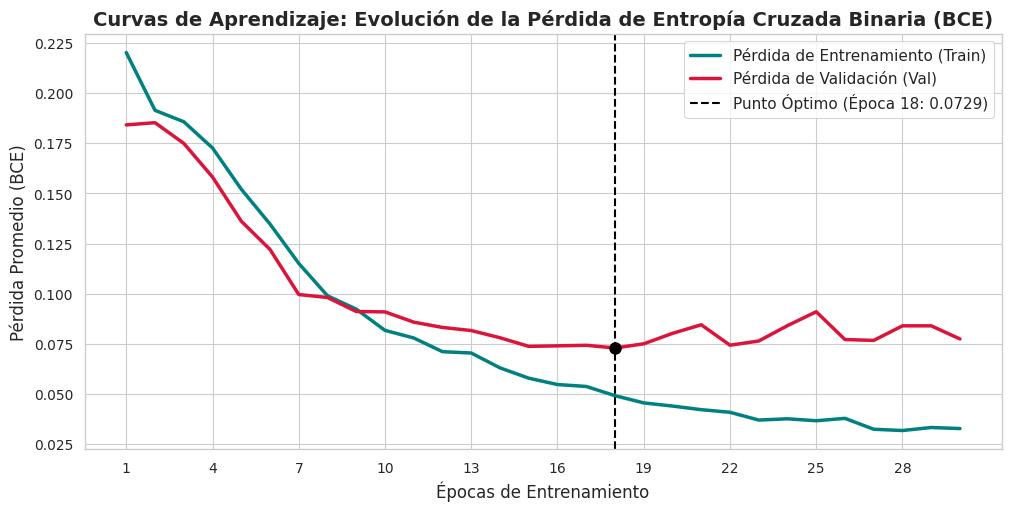

Curva de aprendizaje guardada con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/curvas_aprendizaje_BCE.png
  - Punto óptimo de generalización: Época 18 con pérdida de 0.0729


In [11]:
# Asegurar la existencia física del directorio para almacenar las figuras de esta fase
fig_train_dir = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(fig_train_dir, exist_ok=True)

# 1. Configurar y graficar el lienzo de curvas de aprendizaje (con constrained_layout activo)
plt.figure(figsize=(10, 5), constrained_layout=True)

# Graficar curvas de pérdida con colores de alto contraste científico
plt.plot(train_losses, label="Pérdida de Entrenamiento (Train)", color="teal", linewidth=2.5)
plt.plot(val_losses, label="Pérdida de Validación (Val)", color="crimson", linewidth=2.5)

# 2. Calcular de forma dinámica el punto óptimo (mínima pérdida de validación)
min_val_loss_epoch = np.argmin(val_losses)
min_val_loss = val_losses[min_val_loss_epoch]

# Dibujar una línea vertical punteada en la época óptima
plt.axvline(
    min_val_loss_epoch, 
    color="black", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Punto Óptimo (Época {min_val_loss_epoch + 1}: {min_val_loss:.4f})"
)
# Colocar un marcador de punto en la intersección óptima
plt.plot(min_val_loss_epoch, min_val_loss, "o", color="black", markersize=8)

# 3. Configurar escala tipográfica y legibilidad de los textos para informes (fuentes grandes)
plt.title("Curvas de Aprendizaje: Evolución de la Pérdida de Entropía Cruzada Binaria (BCE)", fontsize=14, fontweight="bold")
plt.xlabel("Épocas de Entrenamiento", fontsize=12)
plt.ylabel("Pérdida Promedio (BCE)", fontsize=12)

# Ajustar las etiquetas del eje X para que coincidan con la numeración de épocas (de 1 en adelante)
plt.xticks(np.arange(0, CONFIG["epochs"], 3), labels=np.arange(1, CONFIG["epochs"] + 1, 3))
plt.tick_params(axis="both", labelsize=10)
plt.legend(fontsize=11)

# 4. Guardar físicamente la figura en disco en alta resolución (300 DPI) para informes o diapositivas
fig_path_losses = os.path.join(fig_train_dir, "curvas_aprendizaje_BCE.png")
plt.savefig(fig_path_losses, dpi=300)
plt.show()

print("Curva de aprendizaje guardada con éxito:")
print(f"  - Ruta de destino: {os.path.abspath(fig_path_losses)}")
print(f"  - Punto óptimo de generalización: Época {min_val_loss_epoch + 1} con pérdida de {min_val_loss:.4f}")

## 11. Persistencia de Parámetros y Metadatos del Modelo

### 11.1. Consolidación de Pesos y Configuración en el Checkpoint

Una vez concluido el bucle de optimización, el estado de los parámetros se encuentra almacenado de forma volátil en la memoria RAM de la sesión activa de Jupyter. Para poder evaluar el modelo de forma independiente en el conjunto de prueba o desplegarlo en una interfaz gráfica interactiva, debemos persistir estos datos de forma física en el disco duro [5].

Para evitar el riesgo de desajustes de configuración (*config drift*), no guardaremos únicamente las matrices de pesos de la red. Consolidaremos un único archivo de **checkpoint empaquetado** que contendrá [5]:
1.  **`model_state_dict`**: Las matrices de pesos numéricos óptimos calculados para cada capa convolucional, recurrente y lineal de la red [5].
2.  **`class_to_idx`** y **`clases`**: El diccionario taxonómico y el orden exacto de las 10 especies objetivo de Medellín para la decodificación de las predicciones [5].
3.  **`audio_config`**: Las especificaciones físicas del preprocesamiento acústico (tasa de muestreo, salto de ventana, cantidad de filtros Mel y el umbral de confianza óptimo de BirdNET) [5].

Este empaquetado garantiza que las etapas de evaluación y el dashboard carguen de forma automática las especificaciones de audio directamente del archivo `.pth`, logrando un desacoplamiento de código altamente robusto.

In [12]:
# Asegurar la existencia física de la carpeta de artefactos
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Definir la ruta oficial unificada del checkpoint de pesos del proyecto
checkpoint_path_final = os.path.join(ARTIFACTS_DIR, "biosed_crnn_checkpoint.pth")

# Construir el diccionario empaquetado con todos los metadatos de control requeridos para inferencia
checkpoint_data = {
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "clases": clases_lista,
    "seed": SEED,
    "audio_config": {
        "sr": CONFIG["sample_rate"],
        "hop_length": CONFIG["hop_length"],
        "n_mels": CONFIG["n_mels"],
        "threshold_default": CONFIG["conf_threshold"]
    }
}

# Guardar físicamente el archivo en el disco duro de la máquina
torch.save(checkpoint_data, checkpoint_path_final)

print("Checkpoint oficial guardado con éxito:")
print(f"  - Ruta física del archivo: {os.path.abspath(checkpoint_path_final)}")
print(f"  - Tamaño del archivo en disco: {os.path.getsize(checkpoint_path_final) / (1024 * 1024):.2f} MB")
print(f"  - Clases taxonómicas empaquetadas: {len(clases_lista)}")

Checkpoint oficial guardado con éxito:
  - Ruta física del archivo: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/biosed_crnn_checkpoint.pth
  - Tamaño del archivo en disco: 4.89 MB
  - Clases taxonómicas empaquetadas: 10


## 12. Registro y Persistencia del Historial Numérico de Pérdidas

### 12.1. Almacenamiento del Historial de Entrenamiento (`training_history.csv`)

Aunque la visualización gráfica de las curvas de pérdida del modelo es el método de diagnóstico principal, es una práctica metodológica indispensable de reproducibilidad científica guardar de forma física las métricas numéricas crudas obtenidas en cada época [5].

Consolidaremos un DataFrame de Pandas que almacene secuencialmente el valor de la pérdida promedio de entrenamiento y validación por época, y lo guardaremos bajo la ruta unificada `artifacts/metrics/training_history.csv` [5]. Este archivo permitirá que el notebook de evaluación (Notebook 04) cargue y analice los datos de convergencia del optimizador sin depender de variables en memoria o de ejecuciones previas de este notebook [5].

In [14]:
# 1. Asegurar la existencia física de la carpeta de métricas de control
metrics_dir = os.path.join(ARTIFACTS_DIR, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Definir la ruta física de destino para el archivo CSV de historial
history_path = os.path.join(metrics_dir, "training_history.csv")

# 2. Compilar el historial numérico en un DataFrame estructurado de Pandas
# Sumamos 1 al range para que la numeración de las épocas empiece formalmente en 1
df_historial = pd.DataFrame({
    "epoca": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses
})

# 3. Guardar físicamente el archivo en el disco sin el índice de pandas
df_historial.to_csv(history_path, index=False)

print("Historial numérico de pérdidas guardado con éxito:")
print(f"  - Ruta de destino: {os.path.abspath(history_path)}")
print(f"  - Épocas registradas en el historial: {len(df_historial)}")
print(f"  - Tamaño del archivo en disco: {os.path.getsize(history_path) / 1024:.2f} KB")

# Mostrar una muestra de los datos guardados
display(df_historial.head(5))

Historial numérico de pérdidas guardado con éxito:
  - Ruta de destino: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/metrics/training_history.csv
  - Épocas registradas en el historial: 30
  - Tamaño del archivo en disco: 1.27 KB


,epoca,train_loss,val_loss
0,1,0.220264,0.184188
1,2,0.191449,0.185285
2,3,0.185760,0.174990
3,4,0.172669,0.158186
4,5,0.152121,0.136165


## 13. Zona Experimental (Área de Pruebas del Modelo)

### 13.1. Lineamientos para la Experimentación del Modelo

Esta sección está diseñada de forma exclusiva como un entorno de experimentación controlado para que el **encargado del modelado** (tu compañero de equipo) pueda proponer, compilar y ensayar variaciones sobre la arquitectura o los hiperparámetros sin comprometer la estabilidad ni la reproducibilidad del pipeline de datos base que hemos consolidado en este notebook [5].

Para garantizar la consistencia científica del proyecto, se establecen las siguientes pautas de experimentación:
1.  **Modificaciones Estructurales**: Si deseas alterar la cantidad de canales convolucionales, cambiar las dimensiones del tamaño del kernel o modificar las dimensiones ocultas de la BiGRU, declara una nueva clase (por ejemplo, `class CRNN_Experimental(nn.Module)`) en esta sección en lugar de reescribir o sobrescribir la clase `CRNN_BioSED` unificada.
2.  **Aumentación de Datos Acústicos (Data Augmentation)**: Se recomienda experimentar aplicando técnicas de enmascaramiento espectral como *SpecAugment* (enmascarando de forma aleatoria bines de frecuencia o tramos de tiempo sobre el espectrograma Log-Mel antes de alimentarlo a la red) para regularizar los gradientes y combatir de forma directa el sobreajuste observado en las curvas de aprendizaje [5].
3.  **Alineación de Salida**: Cualquier modelo experimental alternativo que propongas debe conservar estrictamente una capa lineal final con activación *Sigmoide* independiente que entregue tensores de dimensiones $[B, T, 10]$, para asegurar compatibilidad directa con las etapas posteriores de evaluación de métricas y despliegue del dashboard [5].

In [15]:
# ==============================================================================
#             PLANTILLA DE PRUEBAS PARA LA ZONA EXPERIMENTAL
# ==============================================================================
# Puedes descomentar y modificar este bloque para proponer variaciones del modelo:

# class CRNN_Experimental(nn.Module):
#     def __init__(self, num_classes=10):
#         super(CRNN_Experimental, self).__init__()
#         
#         # PROPUESTA DE MEJORA: Puedes incrementar el Dropout a 0.3 o 0.4 para añadir 
#         # mayor regularización espacial y combatir el sobreajuste que diagnosticamos 
#         # en el análisis visual de las curvas de pérdida.
#         self.conv_block = nn.Sequential(
#             # Capa Conv 1
#             nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Dropout(0.3),  # Incrementado para robustez
#             nn.MaxPool2d(kernel_size=(1, 2)),
#             
#             # Capa Conv 2
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.MaxPool2d(kernel_size=(1, 2)),
#             
#             # Capa Conv 3
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.MaxPool2d(kernel_size=(1, 2))
#         )
        
        # PROPUESTA DE MEJORA: Puedes experimentar sustituyendo la BiGRU por una BiLSTM
        # o alternando las dimensiones ocultas para evaluar cambios en la inercia temporal
#         self.gru = nn.GRU(
#             input_size=128 * 8, 
#             hidden_size=128, 
#             num_layers=2,
#             batch_first=True, 
#             bidirectional=True, 
#             dropout=0.3
#         )
        
        # La dimensión de la capa lineal se conserva en 256 (hidden_size * 2) si se mantiene la bidireccionalidad
#         self.fc = nn.Linear(in_features=128 * 2, out_features=num_classes)
#         self.sigmoid = nn.Sigmoid()
        
#     def forward(self, x):
        # El flujo del tensor conserva la misma secuencia matemática para asegurar compatibilidad
#         x = self.conv_block(x)
#         batch, c, frames, m = x.shape
#         x = x.permute(0, 2, 1, 3)
#         x = x.reshape(batch, frames, c * m)
#         x, _ = self.gru(x)
#         y_prob = self.sigmoid(self.fc(x))
#         return y_prob